In [62]:
import numpy as np
import torch as to

to.tensor([2,3,4])

tensor([2, 3, 4])

In [63]:
x = to.tensor(3.0, requires_grad=True)

y = x ** 3 + x

y.backward()

x.grad

tensor(28.)

In [64]:
import torch

w = torch.tensor(5.5, requires_grad=True)

x = torch.tensor(2.0)

pred = w * x

actual = torch.tensor(11)

loss = (actual - pred) ** 2

loss.backward()

print(w.grad)

tensor(-0.)


In [65]:
import torch.nn as nn
import torch.nn.functional as F


X = torch.tensor([ 
    [2.0, 4.0],
    [8.0, 7.0],
    [1.0, 3.0],
    [9.0, 8.0],
    [3.0, 5.0],
    [7.0, 6.0],    
])

y = torch.tensor([[0.], [1.], [0.], [1.], [0.], [1.]])

model = nn.Sequential(
        nn.Linear(2, 4),
        nn.ReLU(),
        nn.Linear(4, 1),
        nn.Sigmoid()
)

pred = model(X)

loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 100
for i in range(epochs):
    pred = model(X)
    loss = loss_fn(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(loss.item())



0.7128515243530273
0.7003968358039856
0.6957929730415344
0.6941099166870117
0.6934971213340759


In [66]:
test = torch.tensor([7.0, 8.0])

with torch.no_grad():
   pred = model(test)

pred

tensor([0.4920])

In [67]:
import torchvision
import torchvision.transforms as transforms
from torchvision import transforms
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
test = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=transform)

trainLoader = torch.utils.data.DataLoader(train, batch_size=32, shuffle=True)
testLoader = torch.utils.data.DataLoader(test, batch_size=32, shuffle=False)

train.classes[6]


'frog'

tensor([[[-0.5373, -0.6627, -0.6078,  ...,  0.2392,  0.1922,  0.1608],
         [-0.8745, -1.0000, -0.8588,  ..., -0.0353, -0.0667, -0.0431],
         [-0.8039, -0.8745, -0.6157,  ..., -0.0745, -0.0588, -0.1451],
         ...,
         [ 0.6314,  0.5765,  0.5529,  ...,  0.2549, -0.5608, -0.5843],
         [ 0.4118,  0.3569,  0.4588,  ...,  0.4431, -0.2392, -0.3490],
         [ 0.3882,  0.3176,  0.4039,  ...,  0.6941,  0.1843, -0.0353]],

        [[-0.5137, -0.6392, -0.6235,  ...,  0.0353, -0.0196, -0.0275],
         [-0.8431, -1.0000, -0.9373,  ..., -0.3098, -0.3490, -0.3176],
         [-0.8118, -0.9451, -0.7882,  ..., -0.3412, -0.3412, -0.4275],
         ...,
         [ 0.3333,  0.2000,  0.2627,  ...,  0.0431, -0.7569, -0.7333],
         [ 0.0902, -0.0353,  0.1294,  ...,  0.1608, -0.5137, -0.5843],
         [ 0.1294,  0.0118,  0.1137,  ...,  0.4431, -0.0745, -0.2784]],

        [[-0.5059, -0.6471, -0.6627,  ..., -0.1529, -0.2000, -0.1922],
         [-0.8431, -1.0000, -1.0000,  ..., -0

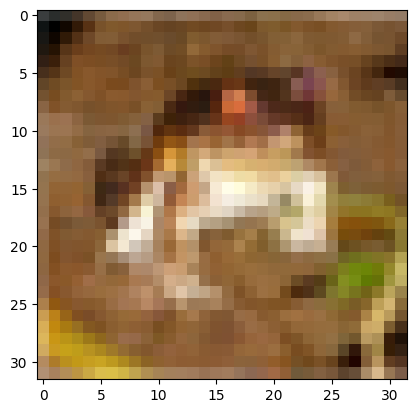

In [68]:
image, label = train[0]
print(image,"\n Label ", label)
train.classes[label]

img = image / 2 + 0.5  # reverse normalization
img = img.permute(1, 2, 0)

plt.imshow(img)

torch.Size([32, 3, 32, 32])


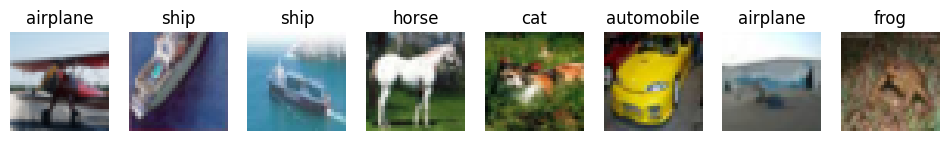

In [69]:
# grab one batch
images, labels = next(iter(trainLoader))

print(images.shape)  # torch.Size([32, 3, 32, 32])
#                                   ↑   ↑   ↑   ↑
#                                batch  RGB  H   W

# show 8 images
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = images[i] * 0.5 + 0.5       # undo normalization for display
    axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[i].set_title(train.classes[labels[i]])
    axes[i].axis('off')
plt.show()

In [70]:
import torch.nn as nn
import torch.nn.functional as F
from torch import functional

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)

        self.fc2 = nn.Linear(512, 10)


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x




In [71]:
model = CNN()

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [78]:
images, labels = next(iter(trainLoader))
print(images.shape)
print(labels.shape)
print(labels.shape[0])

print((model.forward(images)).shape)

print(model(images).shape)


torch.Size([32, 3, 32, 32])
torch.Size([32])
32
torch.Size([32, 10])
torch.Size([32, 10])


In [77]:
from torch import optim

loss_fn_multi = nn.CrossEntropyLoss()
optimizer_simple = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(2):
    total = 0
    correct = 0
    print("HI")
    for images, labels in trainLoader:
        print("Bye")
        optimizer_simple.zero_grad()
        output = model(images)
        loss = loss_fn_multi(output, labels)

        loss.backward()

        optimizer_simple.step()
        _, predicted = torch.max(output, 1)
    
        correct += (predicted == labels).sum().item()
        total += labels.shape[0]

    acc = (correct/total) * 100

    print(acc)
        

HI
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye
Bye


KeyboardInterrupt: 